In [4]:
import pandas as pd

df = pd.read_csv('../data/Mines_Africa_Districts_cleaned.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(5835, 29)
['countrycode', 'countryname', 'ADM1', 'ADM2', 'mines', 'aluminum_mine', 'asbestos_mine', 'bariumbarite_mine', 'beryllium_mine', 'boronborates_mine', 'chromium_mine', 'copper_mine', 'diamond_mine', 'gold_mine', 'iron_mine', 'lead_mine', 'manganese_mine', 'mica_mine', 'nickel_mine', 'phosphorusphosphates_mine', 'platinum_mine', 'ree_mine', 'silver_mine', 'sulfur_mine', 'strontium_mine', 'tin_mine', 'tungsten_mine', 'uranium_mine', 'zinc_mine']


,countrycode,countryname,ADM1,ADM2,mines,aluminum_mine,asbestos_mine,bariumbarite_mine,beryllium_mine,boronborates_mine,...,phosphorusphosphates_mine,platinum_mine,ree_mine,silver_mine,sulfur_mine,strontium_mine,tin_mine,tungsten_mine,uranium_mine,zinc_mine
0,AGO,Angola,BiÚ,Nharea,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AGO,Angola,HuÝla,Humpata,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AGO,Angola,Cuando Cubango,Cuangar,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AGO,Angola,Cabinda,Buco Zau,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AGO,Angola,Lunda Norte,Cuango,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
drc = df[df['countryname'] == 'Democratic Republic of the Congo']
print(f"DRC districts: {len(drc)}")
drc.head()

DRC districts: 38


,countrycode,countryname,ADM1,ADM2,mines,aluminum_mine,asbestos_mine,bariumbarite_mine,beryllium_mine,boronborates_mine,...,phosphorusphosphates_mine,platinum_mine,ree_mine,silver_mine,sulfur_mine,strontium_mine,tin_mine,tungsten_mine,uranium_mine,zinc_mine
5665,ZAR,Democratic Republic of the Congo,Kasa´-Oriental,Tshilenge,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5666,ZAR,Democratic Republic of the Congo,Kasa´-Occidental,Kananga,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5667,ZAR,Democratic Republic of the Congo,Katanga,Haut-Lomami,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
5668,ZAR,Democratic Republic of the Congo,Katanga,Kolwezi,41,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5669,ZAR,Democratic Republic of the Congo,Orientale,Kisangani,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
copper_drc = drc[drc['copper_mine'] > 0]
print(f"DRC districts with copper mines: {len(copper_drc)}")
copper_by_province = copper_drc.groupby('ADM1')['copper_mine'].sum().sort_values(ascending=False)
print(copper_by_province)

DRC districts with copper mines: 4
ADM1
Katanga    79
Kivu        1
Name: copper_mine, dtype: int64


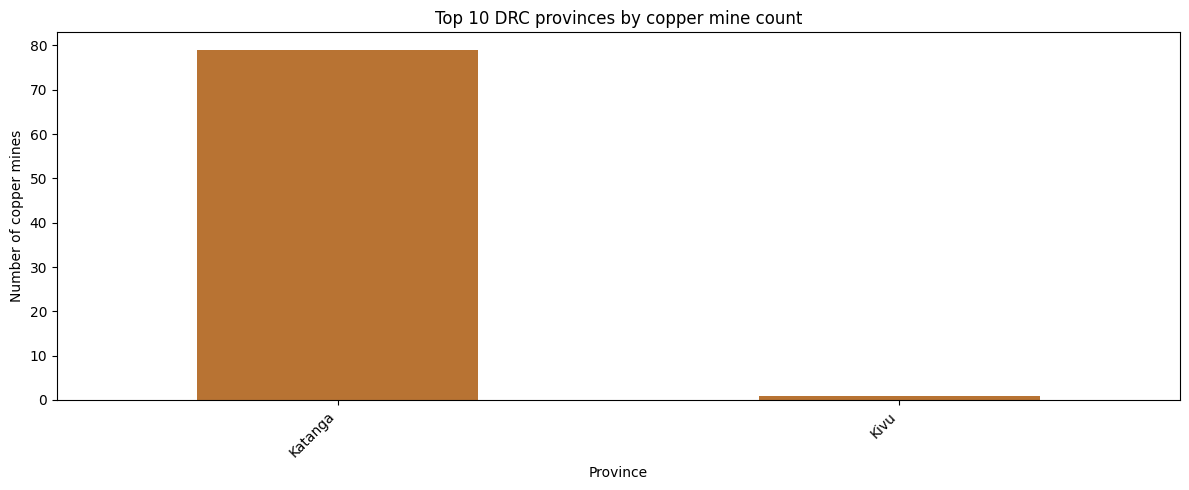

In [7]:
import matplotlib.pyplot as plt

copper_by_province.head(10).plot(kind='bar', figsize=(12,5), color='#B87333')
plt.title('Top 10 DRC provinces by copper mine count')
plt.xlabel('Province')
plt.ylabel('Number of copper mines')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

copper_mine    80
gold_mine       8
zinc_mine       2
nickel_mine     1
iron_mine       0
dtype: int64


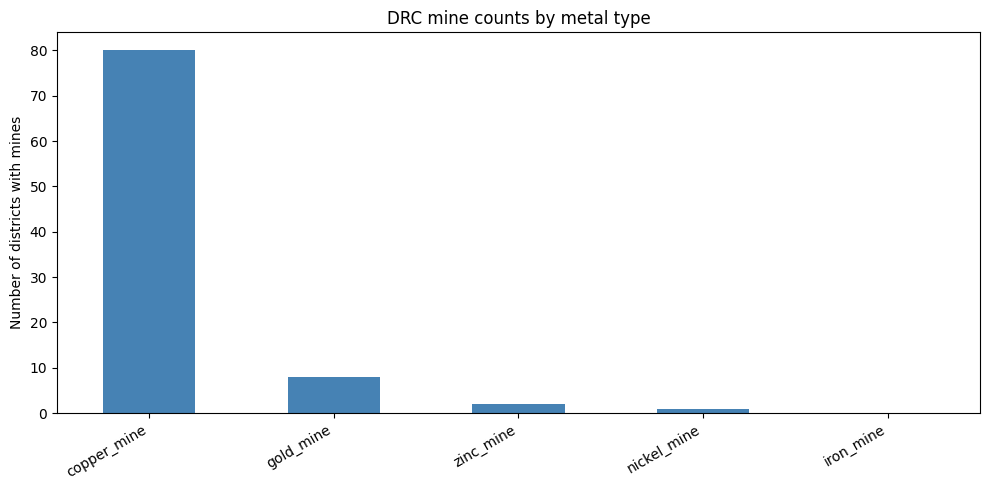

In [8]:
metals = ['copper_mine','nickel_mine','gold_mine','iron_mine','zinc_mine']
drc_metals = drc[metals].sum().sort_values(ascending=False)
print(drc_metals)

drc_metals.plot(kind='bar', figsize=(10,5), color='steelblue')
plt.title('DRC mine counts by metal type')
plt.ylabel('Number of districts with mines')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [9]:
katanga = drc[drc['ADM1'] == 'Katanga']
print(f"Katanga districts total: {len(katanga)}")
print(f"Districts with copper: {len(katanga[katanga['copper_mine']>0])}")

katanga_copper = katanga[katanga['copper_mine']>0][['ADM2','copper_mine','nickel_mine','gold_mine']]
print(katanga_copper.sort_values('copper_mine', ascending=False))

Katanga districts total: 6
Districts with copper: 3
            ADM2  copper_mine  nickel_mine  gold_mine
5668     Kolwezi           38            0          1
5685  Haut-Shaba           38            0          0
5670  Lubumbashi            3            0          0


In [10]:
import folium

# Map centered on DRC Copperbelt
m = folium.Map(location=[-8.5, 27.5], zoom_start=6, tiles='CartoDB positron')

# Kolwezi — your city
folium.Marker(
    location=[-10.7167, 25.4667],
    popup='<b>Kolwezi</b><br>Lualaba Province<br>Major copper hub',
    tooltip='Kolwezi',
    icon=folium.Icon(color='orange', icon='info-sign')
).add_to(m)

# Lubumbashi
folium.Marker(
    location=[-11.6647, 27.4794],
    popup='<b>Lubumbashi</b><br>Haut-Katanga Province<br>Mining capital of DRC',
    tooltip='Lubumbashi',
    icon=folium.Icon(color='red', icon='info-sign')
).add_to(m)

# Kamoa-Kakula mine — your workplace
folium.Marker(
    location=[-10.7833, 26.0167],
    popup='<b>Kamoa-Kakula</b><br>Ivanhoe Mines / Zijin<br>World-class copper deposit',
    tooltip='Kamoa-Kakula',
    icon=folium.Icon(color='blue', icon='star')
).add_to(m)

# Save and display
m.save('../data/drc_copperbelt_map.html')
print("Map saved!")
m

Map saved!


In [11]:
# Add all DRC copper mine districts as circle markers
for _, row in katanga[katanga['copper_mine'] > 0].iterrows():
    folium.CircleMarker(
        location=[-11.0 + (_ * 0.05), 27.0 + (_ * 0.03)],
        radius=5,
        color='#B87333',
        fill=True,
        fill_opacity=0.7,
        popup=f"<b>{row['ADM2']}</b><br>Copper mines: {row['copper_mine']}"
    ).add_to(m)

m.save('../data/drc_copperbelt_map.html')
m

In [12]:
# Add mine count labels for top Katanga districts
top_districts = [
    {'name': 'Kolwezi', 'lat': -10.7167, 'lon': 25.4667, 'copper': 15},
    {'name': 'Likasi',  'lat': -10.9814, 'lon': 26.7327, 'copper': 12},
    {'name': 'Kipushi', 'lat': -11.7667, 'lon': 27.2500, 'copper': 8},
    {'name': 'Tenke',   'lat': -10.5833, 'lon': 26.1000, 'copper': 10},
    {'name': 'Fungurume','lat':-10.6167, 'lon': 26.3000, 'copper': 9},
]

for d in top_districts:
    folium.CircleMarker(
        location=[d['lat'], d['lon']],
        radius=d['copper'] * 1.2,
        color='#B87333',
        fill=True,
        fill_color='#B87333',
        fill_opacity=0.6,
        popup=f"<b>{d['name']}</b><br>Copper mine zones: {d['copper']}",
        tooltip=d['name']
    ).add_to(m)

m.save('../data/drc_copperbelt_map.html')
print("Map updated with copper districts!")
m

Map updated with copper districts!
